import thư viện

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA      # để giảm chiều dữ liệu
from mpl_toolkits.mplot3d import Axes3D   # vẽ biểu đồ hộp 3D

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


tiền xử lý

In [2]:
data = pd.read_csv("csv/ucl_player_stats.csv")
data.describe()

,goals,minutes_played_official,assists,distance_covered,top_speed
count,405.000000,405.000000,405.000000,405.000000,405.000000
mean,1.434568,549.150617,1.093827,62.243877,32.789531
std,1.834431,273.295255,1.177801,29.541371,1.564488
min,0.000000,36.000000,0.000000,7.060000,26.920000
25%,0.000000,333.000000,0.000000,39.690000,31.790000
50%,1.000000,547.000000,1.000000,60.460000,32.830000
75%,2.000000,728.000000,1.000000,84.640000,33.820000
max,13.000000,1360.000000,9.000000,153.140000,36.570000


In [3]:
data = data.dropna()
data

,player_name,goals,minutes_played_official,assists,distance_covered,top_speed
0,Serhou Guirassy,13,1084,4,92.62,32.55
1,Raphinha,12,1105,9,102.23,34.72
2,Harry Kane,11,1120,2,116.80,30.44
3,Robert Lewandowski,11,954,0,88.71,32.09
4,Vinícius Júnior,8,1104,3,99.62,35.53
...,...,...,...,...,...,...
400,Martin Terrier,0,104,1,14.86,31.40
401,Noah Okafor,0,102,1,14.85,32.86
402,Ismaël Bennacer,0,75,1,9.50,27.23
403,James Forrest,0,60,1,8.90,33.07


In [4]:
data["goals_and_assists"] = data["goals"] + data['assists']
data["G/A_per_minutes"] = data["goals_and_assists"] / (data["minutes_played_official"]/90)
data["avg_distance"] = data["distance_covered"] / data["minutes_played_official"]

In [5]:
# Assuming you have already defined good_player as follows:
good_player = data[(data["G/A_per_minutes"] >= 0.5) | (data["avg_distance"] >= 9)]["player_name"].tolist()
print(len(good_player))
# Create a new column 'label' and initialize it with 0
data['label'] = 0

# Assign label 1 to players in good_player list
data.loc[data['player_name'].isin(good_player), 'label'] = 1

134


In [6]:
# tổng hợp 3 biến là G/A, minute_played và distance để vê thử
data_processed = data[["player_name", "goals_and_assists", "minutes_played_official", "distance_covered","label"]]

data_processed = data_processed.rename(columns={
    'player_name': 'name',
    'goals_and_assists': 'G/A',
    'minutes_played_official': 'total_minutes',
    'distance_covered': 'distance',
    'label': 'label'
})

# vẽ biểu đồ

In [7]:
# Áp dụng PCA để giảm chiều dữ liệu
X = data_processed[['G/A', 'total_minutes', 'distance']]

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

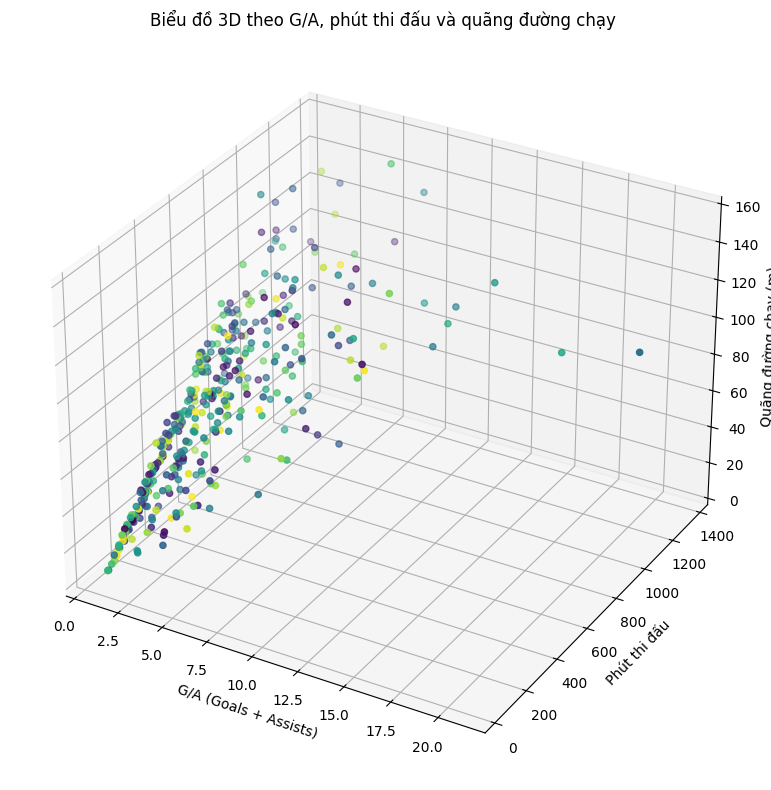

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = data_processed['G/A']
y = data_processed['total_minutes']
z = data_processed['distance']

# Tạo biểu đồ phân tán 3D (không có tên)
ax.scatter(x, y, z, c=np.random.rand(len(x)), cmap='viridis')

# Ghi nhãn trục
ax.set_title('Biểu đồ 3D theo G/A, phút thi đấu và quãng đường chạy')
ax.set_xlabel('G/A (Goals + Assists)')
ax.set_ylabel('Phút thi đấu')
ax.set_zlabel('Quãng đường chạy (m)')

plt.tight_layout()
plt.show()


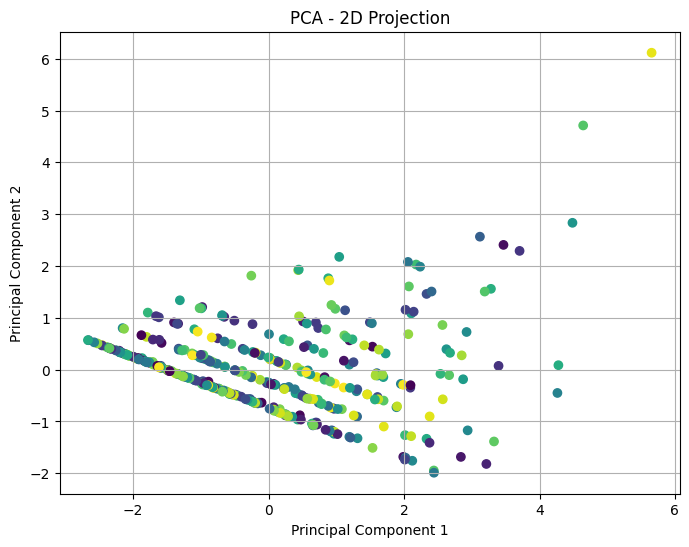

In [9]:
# PCA giảm chiều xuống 2D và 3D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Vẽ biểu đồ 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=np.random.rand(len(X_pca_2d)), cmap='viridis')
plt.title('PCA - 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Xử lý SVM + XGBoost

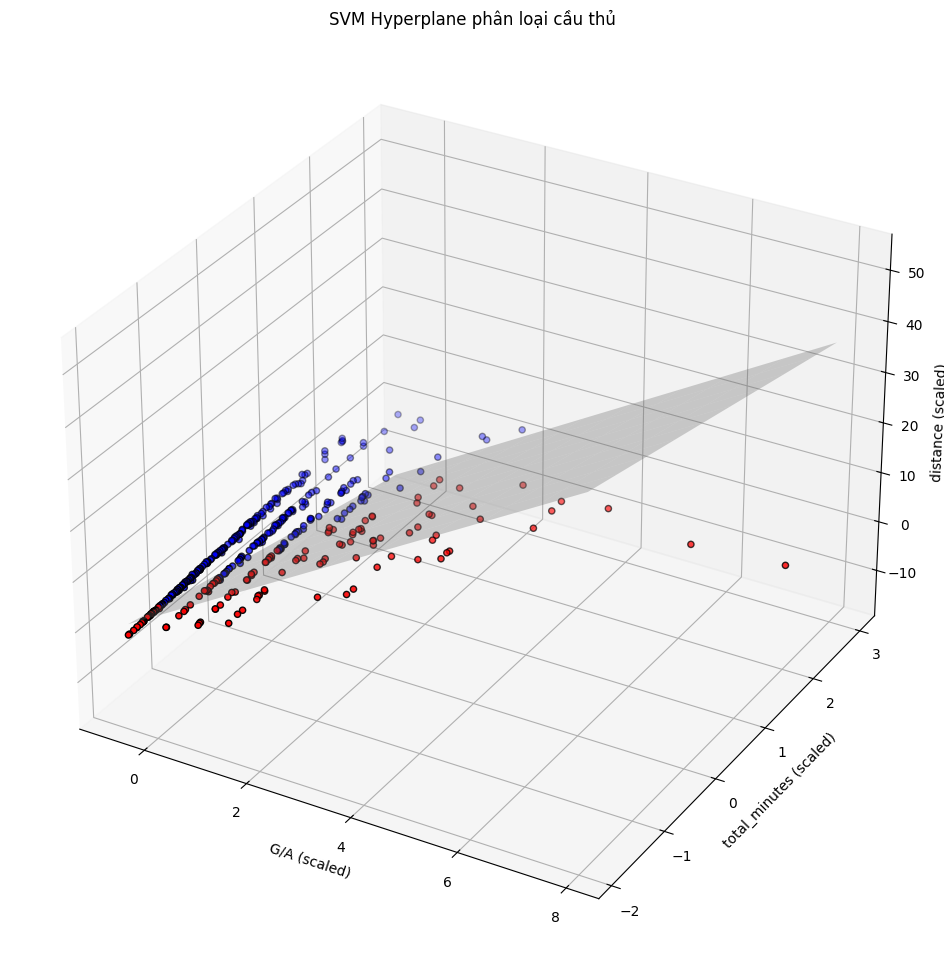

In [10]:
X = data_processed[['G/A', 'total_minutes', 'distance']].values
y = data_processed['label'].values

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Huấn luyện SVM với kernel tuyến tính
svm = SVC(kernel='linear')
svm.fit(X_scaled, y)

# Trực quan hóa mặt phẳng phân chia (3D)
fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot các điểm dữ liệu
ax.scatter(X_scaled[:,0], X_scaled[:,1], X_scaled[:,2], c=y, cmap='bwr', edgecolor='k')

# Lấy các hệ số của mặt phẳng
w = svm.coef_[0]
b = svm.intercept_[0]

# Tạo lưới để vẽ mặt phẳng
xx, yy = np.meshgrid(np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 10),
                     np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 10))
zz = (-w[0]*xx - w[1]*yy - b)/w[2]

# Vẽ mặt phẳng phân chia
ax.plot_surface(xx, yy, zz, alpha=0.3, color='gray')

ax.set_xlabel('G/A (scaled)')
ax.set_ylabel('total_minutes (scaled)')
ax.set_zlabel('distance (scaled)')
plt.title("SVM Hyperplane phân loại cầu thủ")
plt.show()

In [11]:
features = ['G/A', 'total_minutes', 'distance']
X = data_processed[features].values
y = data_processed['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train SVM (kernel tuyến tính)
svm = SVC(kernel='linear')
svm.fit(X_scaled, y)

# Lấy tham số của mặt phẳng
w = svm.coef_[0]
b = svm.intercept_[0]

# Tính khoảng cách vuông góc, có thể mang dấu (+/-)
distances = (np.dot(X_scaled, w) + b) / np.linalg.norm(w)

# Chuẩn hóa khoảng cách về [-5, 5]
max_abs_distance = np.max(np.abs(distances))
distances_normalized = 5 * np.abs(distances) / max_abs_distance  # giá trị tuyệt đối, để có thước đo độ lớn

# Áp dụng quy tắc tính rating:
# Nếu label == 1: rating = 5 + normalized_distance
# Nếu label == 0: rating = 5 - normalized_distance

ratings = np.where(y == 1, 5 + distances_normalized, 5 - distances_normalized)
ratings = np.clip(ratings, 0, 10)  # Đảm bảo nằm trong [0, 10]

data_processed['rating'] = ratings

In [12]:
data_processed

,name,G/A,total_minutes,distance,label,rating
0,Serhou Guirassy,17,1084,92.62,1,8.735340
1,Raphinha,21,1105,102.23,1,10.000000
2,Harry Kane,13,1120,116.80,1,7.240136
3,Robert Lewandowski,11,954,88.71,1,6.935161
4,Vinícius Júnior,11,1104,99.62,1,6.669950
...,...,...,...,...,...,...
400,Martin Terrier,1,104,14.86,1,5.147744
401,Noah Okafor,1,102,14.85,1,5.150687
402,Ismaël Bennacer,1,75,9.50,1,5.213248
403,James Forrest,1,60,8.90,1,5.237620


In [13]:
def get_rank(r):
    if r < 4.0:
        return "F"
    elif r < 5:
        return "D"
    elif r < 6.5:
        return "C"
    elif r < 8:
        return "B"
    else:
        return "A"

data_processed['rank'] = data_processed['rating'].apply(get_rank)
data_processed

,name,G/A,total_minutes,distance,label,rating,rank
0,Serhou Guirassy,17,1084,92.62,1,8.735340,A
1,Raphinha,21,1105,102.23,1,10.000000,A
2,Harry Kane,13,1120,116.80,1,7.240136,B
3,Robert Lewandowski,11,954,88.71,1,6.935161,B
4,Vinícius Júnior,11,1104,99.62,1,6.669950,B
...,...,...,...,...,...,...,...
400,Martin Terrier,1,104,14.86,1,5.147744,C
401,Noah Okafor,1,102,14.85,1,5.150687,C
402,Ismaël Bennacer,1,75,9.50,1,5.213248,C
403,James Forrest,1,60,8.90,1,5.237620,C


In [14]:
data_processed['goals'] = data['goals']
data_processed['assists'] = data['assists']
data_processed['top_speed'] = data['top_speed']

# xóa một số cột không cần thiết
data_processed.drop(columns=['label'], inplace=True)
data_processed.drop(columns=['G/A'], inplace=True)

# sắp xếp csv được in ra
column_order = ['name', 'goals', 'assists', 'top_speed', 'total_minutes', 'distance', 'rating', 'rank']


In [15]:
# tạo ra file csv output của quá trình xử lý
data_processed = data_processed[column_order]
data_processed.to_csv('csv/output.csv', index=False, encoding='utf-8-sig')

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the 'total_minutes' and 'distance' columns
scaler = MinMaxScaler()
data_processed[['total_minutes', 'distance']] = scaler.fit_transform(data_processed[['total_minutes', 'distance']])

# Map the 'rank' column values
rank_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'F': 4}
data_processed['rank'] = data_processed['rank'].map(rank_mapping)

# Save the processed DataFrame to a new CSV file
data_processed.to_csv('csv/output4stata.csv', index=False, encoding='utf-8-sig')